In [17]:
import pandas as pd
import numpy as np


In [18]:
data=pd.read_csv('iris_data.csv')
data.head()

,sepal length,sepal width,petal length,petal width,target,label
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [19]:
x=data.drop(['target','label'],axis=1)
y=data.loc[:,'label']


In [20]:
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier(n_neighbors=3)
KNN.fit(x,y)
y_pred=KNN.predict(x)
print(y_pred)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1
 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 1 2 2 2 2
 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [21]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(y,y_pred)
print(acc)

0.96


In [22]:
from sklearn.preprocessing import StandardScaler
x_norm=StandardScaler().fit_transform(x)

In [25]:
x_mean=x.loc[:,'sepal length'].mean()
x_norm_mean=x_norm[:,0].mean()
x_sigma=x.loc[:,'sepal length'].std()
x_norm_sigma=x_norm[:,0].std()
print(x_norm_mean,x_norm_sigma)


-4.736951571734001e-16 1.0


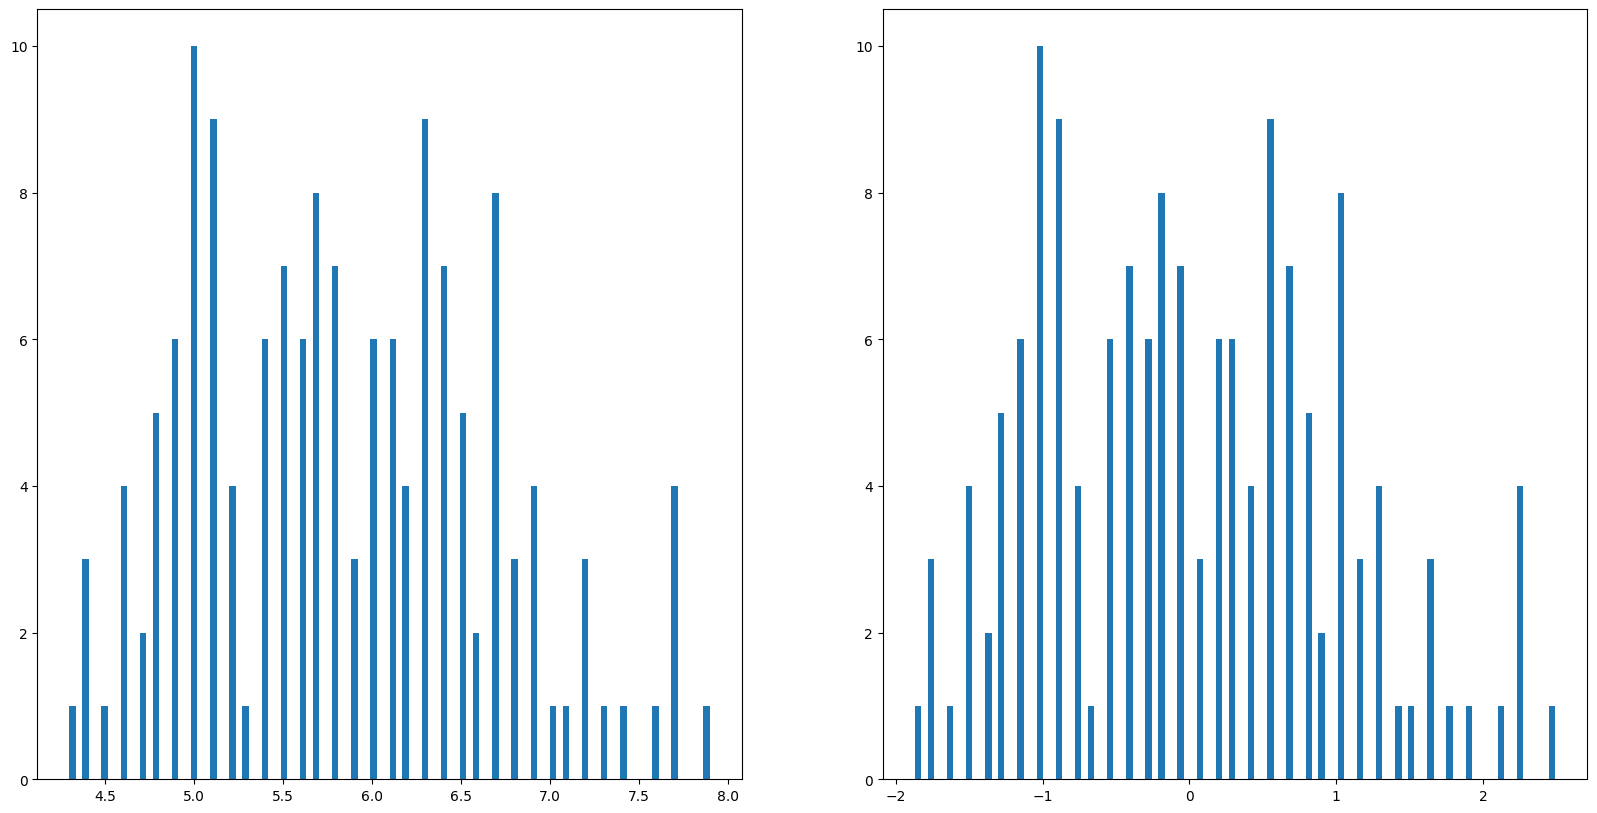

In [24]:
from matplotlib import pyplot as plt
fig1=plt.figure(figsize=[20,10])
plt.subplot(121)
plt.hist(x.loc[:,'sepal length'],bins=100)
plt.subplot(122)
plt.hist(x_norm[:,0],bins=100)
plt.show()

pca处理

In [26]:
from sklearn.decomposition import PCA
pca=PCA(n_components=4)
x_pca=pca.fit_transform(x_norm)
var_ratio=pca.explained_variance_ratio_
print(var_ratio)


[0.72770452 0.23030523 0.03683832 0.00515193]


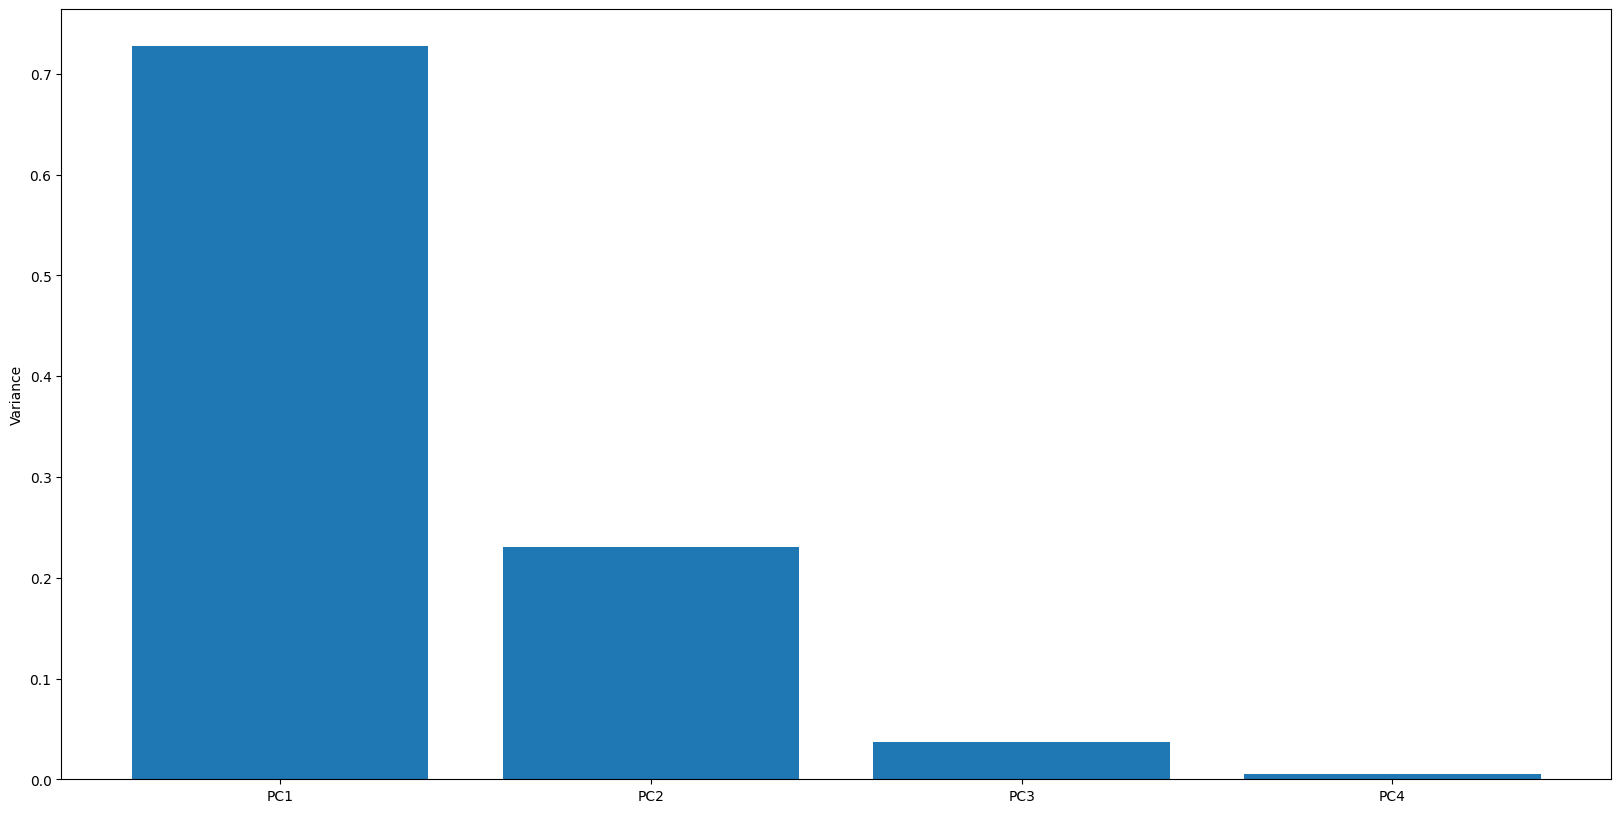

In [34]:
fig2=plt.figure(figsize=[20,10])
plt.bar([1,2,3,4],var_ratio)
plt.xticks([1,2,3,4],['PC1','PC2','PC3','PC4'])
plt.ylabel('Variance')
plt.show()

In [35]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_norm)
x_pca.shape

(150, 2)

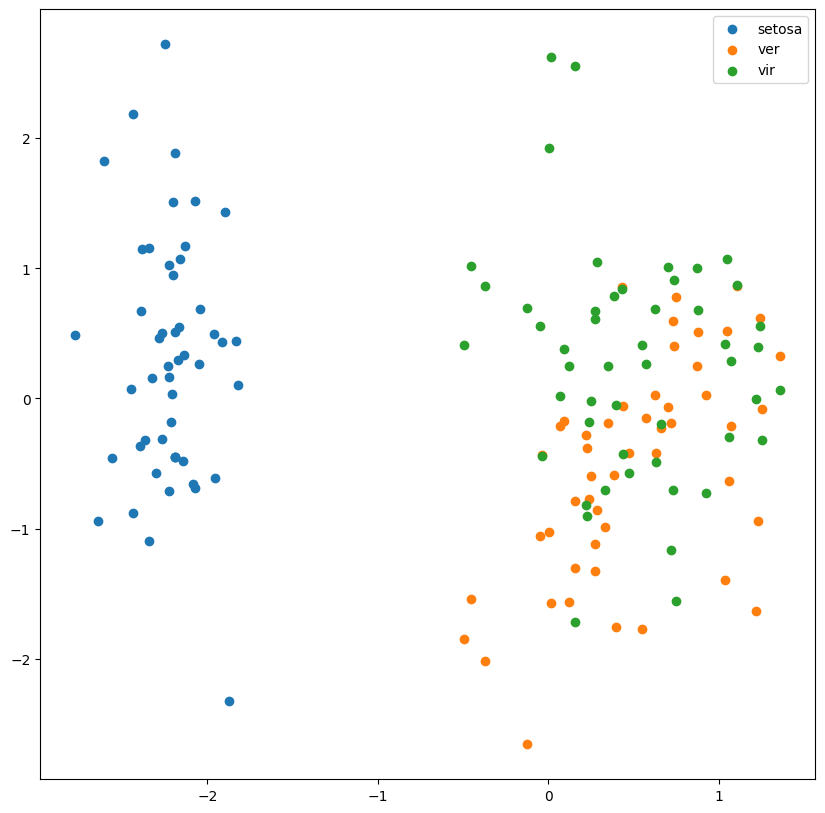

In [41]:
fig3=plt.figure(figsize=[10,10])
setosa=plt.scatter(x_pca[:,0][y==0],x_pca[:,1][y==0])
versicolor=plt.scatter(x_pca[:,0][y==1],x_pca[:,1][y==1])
virginica=plt.scatter(x_pca[:,0][y==1],x_pca[:,1][y==2])
plt.legend([setosa,versicolor,virginica],['setosa','versicolor','virginica'])
plt.show()

In [48]:
KNN=KNeighborsClassifier(n_neighbors=3)
KNN.fit(x_pca,y)
y_pred=KNN.predict(x_pca)
print(y_pred)
acc=accuracy_score(y,y_pred)
print(acc)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 2 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1
 1 1 1 2 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 1 2 2 2 2
 2 2 1 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
0.9466666666666667
